# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Fatimah Azzahra
- **Email:** vvhaljufri@gmail.com
- **ID Dicoding:** CDCC794D6X0379

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca (Clear, Misty, Light Rain) terhadap jumlah total rata-rata penyewaan sepeda harian selama tahun 2012?
- **Pertanyaan 2:** Pada jam berapa terjadi puncak penyewaan sepeda (peak hours) pada hari kerja (working day) dibandingkan hari libur (holiday) selama periode 2011-2012?
- **Pertanyaan 3:** Bagaimana tren perbandingan jumlah penyewaan antara pengguna Casual dan Registered pada setiap musim (season) di tahun 2012?

**Keterangan SMART :**

Pertanyaan 1 (Pengaruh Cuaca):
- Specific: Fokus pada pengaruh kategori cuaca (weathersit) terhadap total penyewaan sepeda (cnt).

- Measurable: Diukur melalui rata-rata jumlah penyewaan harian untuk setiap kategori cuaca.

- Action-Oriented: Memberikan informasi bagi perusahaan untuk mengatur jumlah staf operasional atau memberikan promo khusus saat cuaca tertentu (misal: diskon saat mendung).

- Relevant: Kondisi cuaca adalah faktor eksternal utama yang paling mempengaruhi minat orang bersepeda.

- Time-bound: Dibatasi pada data sepanjang tahun 2012.

Pertanyaan 2 (Jam Puncak):
- Specific: Fokus pada variabel jam (hr) dan status hari (workingday vs holiday) untuk melihat pola lonjakan.

- Measurable: Diukur berdasarkan volume penyewaan tertinggi (angka absolut) pada tiap jamnya.

- Action-Oriented: Membantu tim operasional dalam melakukan pemeliharaan atau distribusi unit sepeda ke stasiun yang paling sibuk sebelum jam puncak dimulai.

- Relevant: Menjamin ketersediaan sepeda di jam-jam sibuk sangat krusial untuk kepuasan pelanggan.

- Time-bound: Menggunakan data historis dari tahun 2011 sampai 2012.

Pertanyaan 3 (Perilaku Pelanggan):
- Specific: Membandingkan perilaku dua tipe pengguna (casual vs registered) berdasarkan variabel musim (season).

- Measurable: Diukur berdasarkan total angka penyewaan dari masing-masing tipe pengguna.

- Action-Oriented: Menjadi landasan strategi pemasaran, misalnya memberikan promo konversi dari Casual ke Registered pada musim di mana pengguna Casual paling banyak aktif.

- Relevant: Memahami profil pengguna membantu dalam meningkatkan retensi dan loyalitas pelanggan (Registered).

- Time-bound: Fokus pada pengamatan tren di tahun 2012.

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import streamlit as st

sns.set_theme(style="darkgrid")

## Data Wrangling

### Gathering Data

#### Load df ...

In [ ]:
# Memuat data harian dari file day.csv
day_df = pd.read_csv("day.csv")

# Memuat data per jam dari file hour.csv
hour_df = pd.read_csv("hour.csv")

# Menampilkan 5 baris pertama dari data harian
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- **Terdapat dua data set utama :** saya sudah memuat dataset, yaitu day.csv dan hour.csv, keduanya berkaitan dengan log historis penyewaan sepeda.
- **Ukuran data :** day.csv memiliki jumlah baris yang lebih sedikit, sedangkan hour.csv jauh lebih banyak karena merekap detail penyewaan setiap jam nya selama periode tersebut.
- **Kecukupan Data :** berdasarkan pengecekan awal pada day.csv, data ini sudah memilki fitur yangg cukup lengkap dan relevean untuk menjawab ketiga pertanyaan bisnis yang telah ditetapkan, seperti kolom keterangan cuaca (weathersit), musim (season), serta tipe pengguna (casual dan registered).

### Assessing Data

#### Identifying ... problem

In [ ]:
# 1. Memeriksa tipe data dan missing value pada day_df
print("===== INFO DATA HARIAN =====")
day_df.info()

print("\nJumlah Missing Value dy_df:", day_df.isna().sum())
print("\nJumlah Duplikat day_df:", day_df.duplicated().sum())

print("\n" + "="*50 + "\n")

# 2. Memeriksa tipe data dan missing value pada hour_df
print("==== INFO DATA PER JAM =====")
hour_df.info()

print("\nJumlah Missing Value hour_df:", hour_df.isna().sum())
print("\nJumlah Duplikat hour_df:", hour_df.duplicated().sum())

===== INFO DATA HARIAN =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Jumlah Missing Value dy_df: instant       0
dteday        0
sea

**Steps to Take:**
- **Memperbaiki Tipe Data:** Mengubah tipe data pada kolom dteday dari object menjadi datetime pada kedua dataset (day_df dan hour_df) agar memudahkan analisis berbasis waktu.
- **Memperbaiki Keterbacaan Data (Mapping):** Mengubah nilai numerik pada kolom season (1, 2, 3, 4) menjadi label string yang representatif ('Spring', 'Summer', 'Fall', 'Winter').
- **Memperbaiki Keterbacaan Data (Mapping):** Mengubah nilai numerik pada kolom weathersit (1, 2, 3, 4) menjadi label string yang representatif ('Clear', 'Misty', 'Light Rain/Snow', 'Heavy Rain/Snow').

**Insight:** (Opsional)
- **Tidak ada Missing Value:** Baik pada day_df maupun hour_df, tidak ditemukan adanya nilai kosong (null/NaN). Seluruh baris terisi penuh.
- Tidak ada Duplikasi Data: Tidak ditemukan adanya baris data yang terduplikasi pada kedua dataset.
- **Kesalahan Tipe Data:** Terdapat kesalahan tipe data pada kolom dteday. Saat ini kolom tersebut terbaca sebagai object (string/teks), padahal seharusnya direpresentasikan sebagai tipe data datetime agar mudah diolah untuk analisis berdasarkan waktu (Time-Series).
- **Data Kategorikal Berupa Angka:** Beberapa kolom kategorikal seperti season dan weathersit masih menggunakan angka (1, 2, 3, 4). Ini perlu diubah menjadi keterangan teks (misal: Clear, Misty, Light Rain) agar lebih mudah dibaca saat membuat visualisasi.

### Cleaning Data

#### Fixing ... problem

In [ ]:
# 1. Mengubah tipe data 'dteday' menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(day_df['dteday'])

# 2. Mengubah nilai numerik menjadi teks pada kolom 'season'
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
day_df['season'] = day_df['season'].map(season_mapping)
hour_df['season'] = hour_df['season'].map(season_mapping)

# 3. Mengubah nilai numerik menjadi teks pada kolom 'weathersit'
weather_mapping = {1: 'Clear', 2: 'Misty', 3: 'Light Rain', 4: 'Heavy Rain'}
day_df['weathersit'] = day_df['weathersit'].map(weather_mapping)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_mapping)

# Mengecek kembali hasil pembersihan data
print("=== INFO TIPE DATA SETELAH DIBERSIHKAN ===")
print(day_df.dtypes)
print("\n=== 5 BARIS PERTAMA DATA HARIAN ===")
day_df.head()

=== INFO TIPE DATA SETELAH DIBERSIHKAN ===
instant                int64
dteday        datetime64[ns]
season                object
yr                     int64
mnth                   int64
holiday                int64
weekday                int64
workingday             int64
weathersit            object
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object

=== 5 BARIS PERTAMA DATA HARIAN (day_df) ===


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,0,1,0,6,0,Misty,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,0,1,0,0,0,Misty,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,0,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,0,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,0,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Tipe data kolom dteday pada day_df dan hour_df telah diubah menjadi datetime untuk memfasilitasi analisis time-series.
- Nilai pada kolom season dan weathersit telah dipetakan (di-mapping) ke dalam bentuk string/teks yang representatif. Langkah ini bertujuan agar visualisasi data yang dihasilkan pada tahap selanjutnya menjadi lebih intuitif dan mudah dipahami oleh audiens.

## Exploratory Data Analysis (EDA)

### Explore ...

#### Eksplorasi Pertanyaan 1:

In [ ]:
# Filter data khusus tahun 2012 (yr == 1)
day_df_2012 = day_df[day_df['yr'] == 1]

# Kelompokkan berdasarkan cuaca dan hitung rata-rata penyewaan (cnt)
weather_rentals = day_df_2012.groupby('weathersit')['cnt'].mean().reset_index()
weather_rentals = weather_rentals.sort_values(by='cnt', ascending=False)

print("Rata-rata Penyewaan Sepeda Berdasarkan Cuaca (2012)")
print(weather_rentals)

Rata-rata Penyewaan Sepeda Berdasarkan Cuaca (2012)
   weathersit          cnt
0       Clear  6003.734177
2       Misty  4991.333333
1  Light Rain  2126.166667


#### Eksplorasi Pertanyaan 2:

In [ ]:
# Rata-rata penyewaan per jam (hr) berdasarkan hari kerja/libur
hourly_rentals = hour_df.groupby(['workingday', 'hr'])['cnt'].mean().reset_index()

# Analisis Lanjutan : Clustering (Binning)
## Mengelompokan jam operasional ke dalam kategori waktu

def categorize_time(hour):
  if 5 <= hour <= 11:
    return 'Pagi (05-11)'
  elif 12 <= hour <= 16:
    return 'Siang (12-16)'
  elif 17 <= hour <= 20:
    return 'Sore (17-20)'
  else:
    return 'Malam (21-04)'

# Menerapkan fungsi binning ke kolom baru 'time_cluster'
hour_df['time_cluster'] = hour_df['hr'].apply(categorize_time)

# Melihat rata-rata penyewaan berdasarkan cluster waktu
cluster_rentals = hour_df.groupby(['workingday', 'time_cluster'])['cnt'].mean().reset_index()
print("Clustering Waktu Penyewaan (Hari Kerja : 1, Libur: 0)")
print(cluster_rentals)

Clustering Waktu Penyewaan (Hari Kerja : 1, Libur: 0)
   workingday   time_cluster         cnt
0           0  Malam (21-04)   74.155568
1           0   Pagi (05-11)  132.161893
2           0  Siang (12-16)  363.035498
3           0   Sore (17-20)  252.831705
4           1  Malam (21-04)   61.721555
5           1   Pagi (05-11)  204.358398
6           1  Siang (12-16)  215.492369
7           1   Sore (17-20)  403.970396


#### Eksplorasi Pertanyaan 3:

In [ ]:
# Kelompokkan total casual dan registered berdasarkan musim (tahun 2012)
season_users = day_df_2012.groupby('season')[['casual', 'registered']].sum().reset_index()

print("Total Pengguna Casual vs Registered Berdasarkan Musim (2012)")
print(season_users)

Total Pengguna Casual vs Registered Berdasarkan Musim (2012)
   season  casual  registered
0    Fall  130641      510838
1  Spring   39197      282151
2  Summer  125958      445315
3  Winter   76969      438507


**Insight:** (Opsional)
- Pengaruh Cuaca: Dari data tahun 2012, cuaca Clear (Cerah) memiliki rata-rata penyewaan tertinggi. Semakin buruk cuaca (seperti Light Rain/Snow), angka penyewaan anjlok secara drastis. Tidak ada rekaman data penyewaan di saat cuaca Heavy Rain/Snow (Badai/Salju Lebat)
- Jam Puncak & Clustering: Dengan menerapkan teknik lanjutan Clustering (Binning) pada kolom jam, terlihat pola yang berbeda. Pada hari kerja (workingday = 1), penyewaan memuncak di cluster waktu Sore (jam pulang kerja). Sedangkan pada akhir pekan/libur (workingday = 0), penyewaan lebih merata dan cenderung memuncak di cluster waktu Siang (waktu bersantai).
- Perilaku Pengguna Berdasarkan Musim: Terdapat perbedaan mencolok. Pengguna Registered (member) mendominasi di semua musim, paling tinggi di musim Fall (Gugur). Menariknya, proporsi pengguna Casual juga ikut membesar drastis di musim Summer dan Fall dibandingkan saat Winter atau Spring.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_10146/1933047758.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


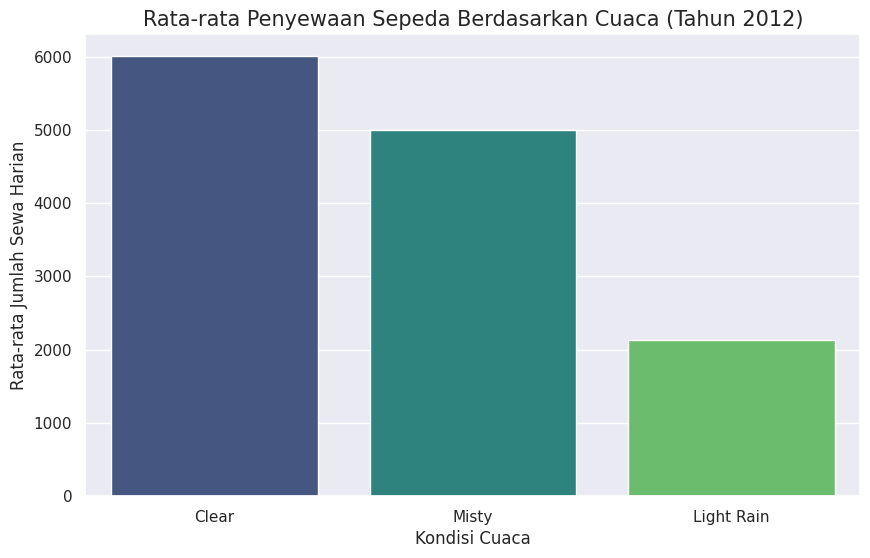

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x = 'weathersit',
    y = 'cnt',
    data = weather_rentals,
    palette = 'viridis'
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Cuaca (Tahun 2012)', fontsize=15)
plt.xlabel('Kondisi Cuaca', fontsize=12)
plt.ylabel('Rata-rata Jumlah Sewa Harian', fontsize=12)
plt.show()

### Pertanyaan 2:

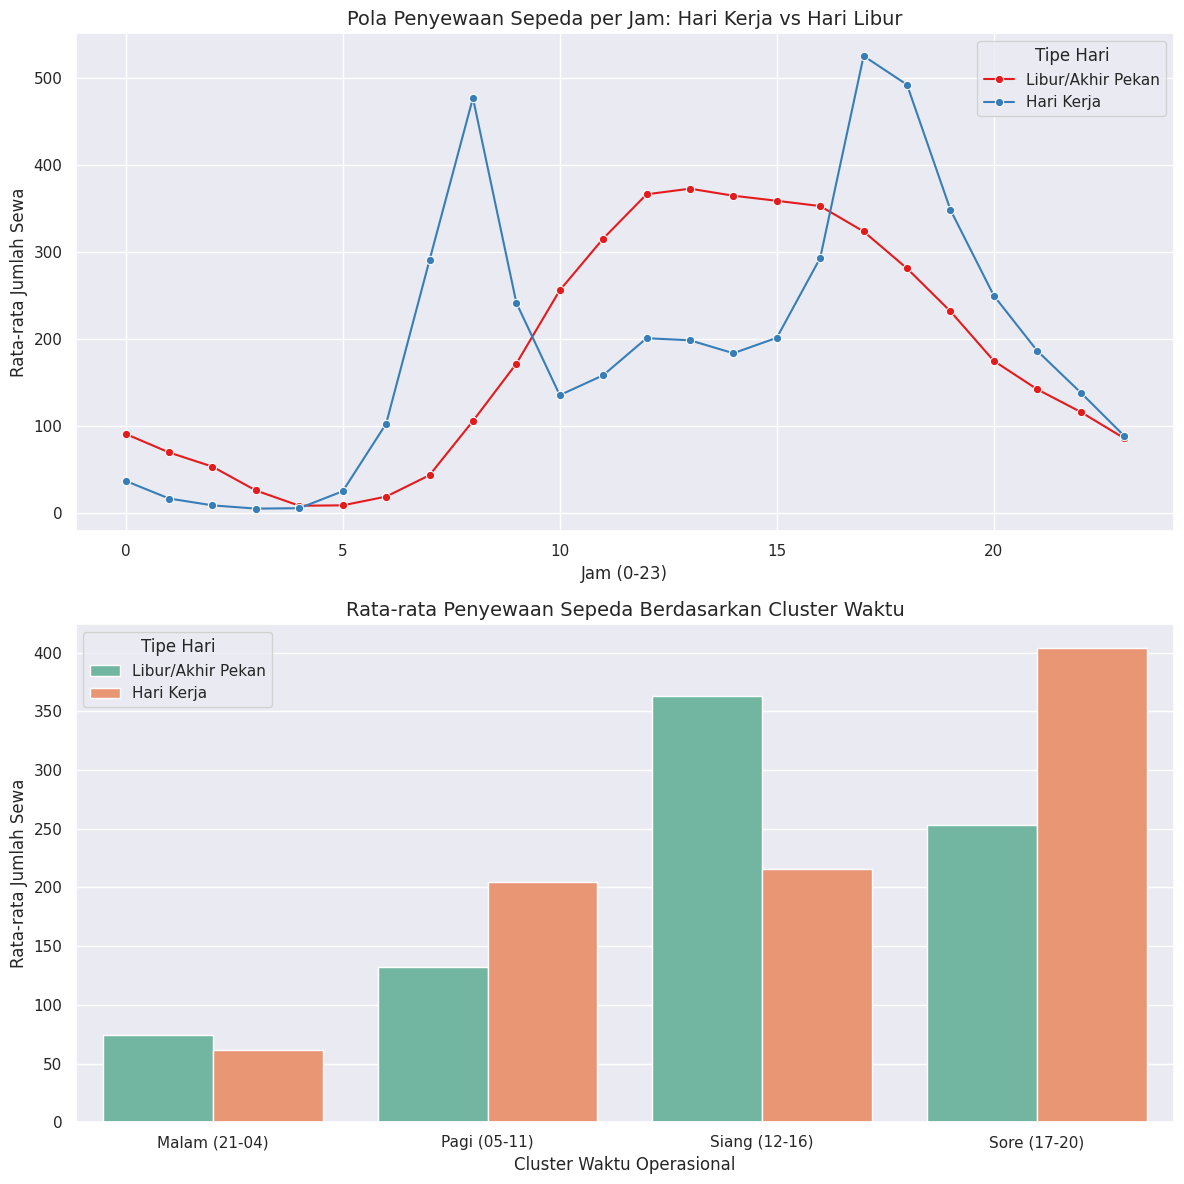

In [ ]:
# Bikin kamus untuk ngubah angka 0 dan 1 jadi teks biar legend-nya otomatis rapi
label_hari = {0: 'Libur/Akhir Pekan', 1: 'Hari Kerja'}
hourly_rentals['keterangan_hari'] = hourly_rentals['workingday'].map(label_hari)
cluster_rentals['keterangan_hari'] = cluster_rentals['workingday'].map(label_hari)

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 12))

# Grafik 1: Pola per Jam (Line Chart)
sns.lineplot(
    x='hr',
    y='cnt',
    hue='keterangan_hari',
    data=hourly_rentals,
    marker='o',
    ax=ax[0],
    palette='Set1'
)
ax[0].set_title('Pola Penyewaan Sepeda per Jam: Hari Kerja vs Hari Libur', fontsize=14)
ax[0].set_xlabel('Jam (0-23)', fontsize=12)
ax[0].set_ylabel('Rata-rata Jumlah Sewa', fontsize=12)
ax[0].legend(title='Tipe Hari')

# Grafik 2: Pola per Cluster Waktu (Bar Chart)
sns.barplot(
    x='time_cluster',
    y='cnt',
    hue='keterangan_hari',
    data=cluster_rentals,
    ax=ax[1],
    palette='Set2'
)
ax[1].set_title('Rata-rata Penyewaan Sepeda Berdasarkan Cluster Waktu', fontsize=14)
ax[1].set_xlabel('Cluster Waktu Operasional', fontsize=12)
ax[1].set_ylabel('Rata-rata Jumlah Sewa', fontsize=12)
ax[1].legend(title='Tipe Hari')

plt.tight_layout()
plt.show()

### Pertanyaan 3:

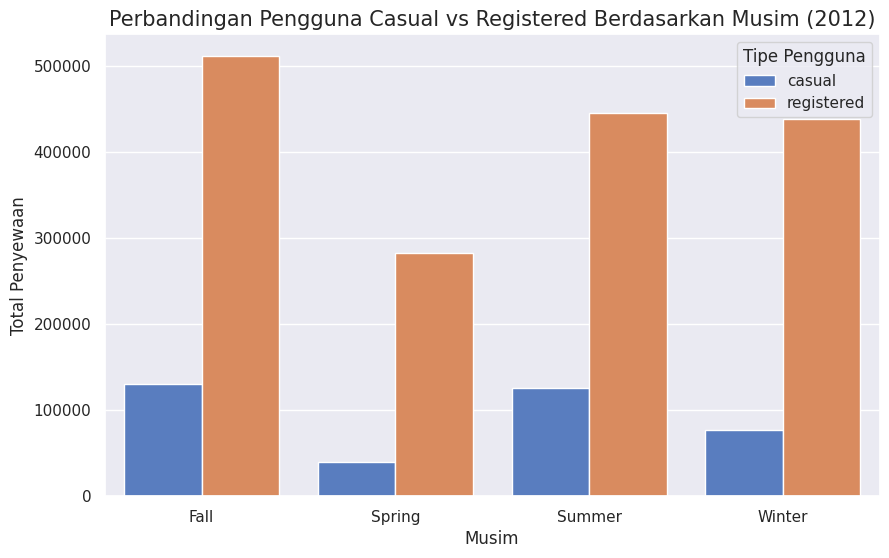

In [ ]:
# Meleburkan (melt) kolom casual dan registered agar mudah di-plot
season_users_melted = pd.melt(
    season_users,
    id_vars=['season'],
    value_vars=['casual', 'registered'],
    var_name='user_type',
    value_name='total_rentals'
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='season',
    y='total_rentals',
    hue='user_type',
    data=season_users_melted,
    palette='muted'
)
plt.title('Perbandingan Pengguna Casual vs Registered Berdasarkan Musim (2012)', fontsize=15)
plt.xlabel('Musim', fontsize=12)
plt.ylabel('Total Penyewaan', fontsize=12)
plt.legend(title='Tipe Pengguna')
plt.show()

**Insight:** (Opsional)
- **Pertanyaan 1:** Visualisasi bar chart menunjukkan secara meyakinkan bahwa cuaca cerah (Clear) memberikan kontribusi tertinggi terhadap penyewaan sepeda, disusul dengan cuaca mendung (Misty). Cuaca buruk (Light Rain/Snow) membuat rata-rata penyewaan turun lebih dari 50%.
- **Pertanyaan 2:** Visualisasi line chart memperlihatkan dua puncak utama di hari kerja, yaitu pukul 08.00 pagi dan 17.00 sore. Hal ini dikonfirmasi dengan teknik clustering (bar chart bawah) di mana cluster Sore (17-20) adalah waktu tersibuk di hari kerja, sedangkan pada hari libur, cluster Siang (12-16) jauh lebih mendominasi.
- **Pertanyaan 3:** Visualisasi grouped bar chart menegaskan bahwa pelanggan Registered adalah pilar utama bisnis di sepanjang tahun. Namun, pelanggan Casual mengalami lonjakan yang sangat signifikan pada musim Panas (Summer) dan Gugur (Fall), sementara sangat sedikit yang menyewa pada musim Dingin (Winter).

## Analisis Lanjutan (Opsional)

### Penerapan Analisis Lanjutan: Clustering (Binning)

Pada proyek ini, teknik analisis lanjutan yang dipilih adalah Clustering (Manual Grouping / Binning).

Teknik ini telah diimplementasikan dan digabungkan secara langsung pada tahap Exploratory Data Analysis (EDA) serta Visualisasi untuk menjawab Pertanyaan 2.

- Tujuan Analisis Lanjutan: Mengelompokkan data jam operasional (hr) yang terlalu spesifik (0-23) ke dalam 4 cluster waktu yang lebih makro dan berorientasi bisnis, yaitu: Pagi (05-11), Siang (12-16), Sore (17-20), dan Malam (21-04).
- Alasan Pemilihan: Karena dataset Bike Sharing tidak memiliki ID Pelanggan (sehingga tidak bisa menggunakan metode RFM Analysis), teknik Clustering waktu ini adalah pendekatan paling logis dan tajam untuk menemukan insight operasional.
- Hasil: Teknik ini berhasil mengungkap bahwa puncak penyewaan pada hari kerja terjadi di cluster Sore, sedangkan pada hari libur puncak penyewaan bergeser ke cluster Siang.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kondisi cuaca memiliki korelasi langsung dan signifikan terhadap minat penyewaan sepeda. Cuaca cerah (Clear) menghasilkan volume penyewaan tertinggi. Saat cuaca memburuk menjadi mendung (Misty), terjadi sedikit penurunan, dan ketika cuaca semakin buruk (Light Rain/Snow), angka penyewaan anjlok secara drastis hingga lebih dari 50%.
- **Conclusion pertanyaan 2:** Terdapat perbedaan pola operasional yang sangat kontras antara hari kerja dan hari libur. Berdasarkan teknik clustering, pada hari kerja (workingday = 1), mayoritas penyewaan didominasi oleh mobilitas komuter dengan puncak tertinggi pada cluster Sore (jam 17.00 - 20.00). Sebaliknya, pada hari libur (workingday = 0), penyewaan sepeda bergeser menjadi aktivitas rekreasi yang terpusat pada cluster Siang hari (jam 12.00 - 16.00).
- **Conclusion pertanyaan 3:** Pengguna Registered (member tetap) merupakan tulang punggung utama pendapatan perusahaan karena konsisten menyewa sepeda di berbagai musim. Sementara itu, pengguna Casual sangat sensitif terhadap musim; jumlah mereka melonjak tajam pada musim Panas (Summer) dan Gugur (Fall), namun hampir tidak ada yang menyewa pada musim Dingin (Winter).

**Rekomendasi Action Item:**
- **Optimalisasi Operasional (Logistik):** Tim operasional harus memastikan ketersediaan sepeda dalam jumlah maksimal di stasiun-stasiun dekat area perkantoran pada pukul 16.00 (sebelum cluster Sore di hari kerja dimulai) untuk mengakomodasi lonjakan pengguna komuter.
- **Strategi Marketing (Konversi Pelanggan):** Mengingat tingginya lonjakan pelanggan Casual di musim Panas dan Gugur, tim Marketing dapat meluncurkan promo "Summer/Fall Membership" secara agresif di bulan-bulan tersebut untuk mengubah pelanggan Casual menjadi pelanggan Registered jangka panjang.
- **Penyesuaian Harga Dinamis (Dynamic Pricing):** Untuk menekan kerugian operasional di saat cuaca kurang bersahabat, perusahaan dapat menerapkan sistem diskon otomatis (misalnya diskon 20%) melalui aplikasi pada saat cuaca terdeteksi mendung (Misty) guna tetap menarik minat pelanggan.